In [1]:
import numpy as np
from numpy import pi
from matplotlib import pyplot as plt
import qutip as qt
from itertools import product

In [4]:
qt.tunneling(5)

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [0. 0. 0. 1. 0.]]

In [ ]:
trunc_num = 81

def e_iphi(N):
  M = np.zeros((N, N), dtype=complex)
  for n in range(N - 1):
    M[n + 1, n] = 1
  return qt.Qobj(M)

def e_m_iphi(N):
  M = np.zeros((N, N), dtype=complex)
  for n in range(N - 1):
    M[n, n + 1] = 1
  return qt.Qobj(M)

def n_op(N):
  M = np.zeros((N, N), dtype=complex)
  offset = (N - 1) / 2
  for n in range(N):
    M[n, n] = n - offset
  return qt.Qobj(M)
  

def H_two_separate_potentials(Ec, trunc_num, Ej1, Ej2, phi):
  return 4 * Ec * n_op(trunc_num) @ n_op(trunc_num) - Ej1 * 1 / 2 * \
         (np.exp(1j * 2 * pi * phi) * e_iphi(trunc_num) +
          np.exp(-1j * 2 * pi * phi) * e_m_iphi(trunc_num)) - Ej2 * 1 / 2 * \
         (e_iphi(trunc_num) + e_m_iphi(trunc_num))

Ec = 218e-3 * 2 * pi
Ej1 = Ec * 70
gamma = 1.5
Ej2 = Ej1 * gamma
d = (gamma - 1) / (gamma + 1)

phi_list = np.linspace(-1, 1, 500)

energies = np.zeros((trunc_num, len(phi_list)))
omegas = np.zeros((trunc_num, len(phi_list)))

for idx, phi in enumerate(phi_list):
  H = H_two_separate_potentials(Ec, trunc_num, Ej1, Ej2, phi)

  evals, _ = H.eigenstates()

  for i in range(trunc_num):
    energies[i][idx] = evals[i]

  for i in range(1, trunc_num):
    omegas[i][idx] = evals[i] - evals[i - 1]


In [99]:
(omegas[2] - omegas[1])[0] / 2 / pi

np.float64(-0.2314954548981407)

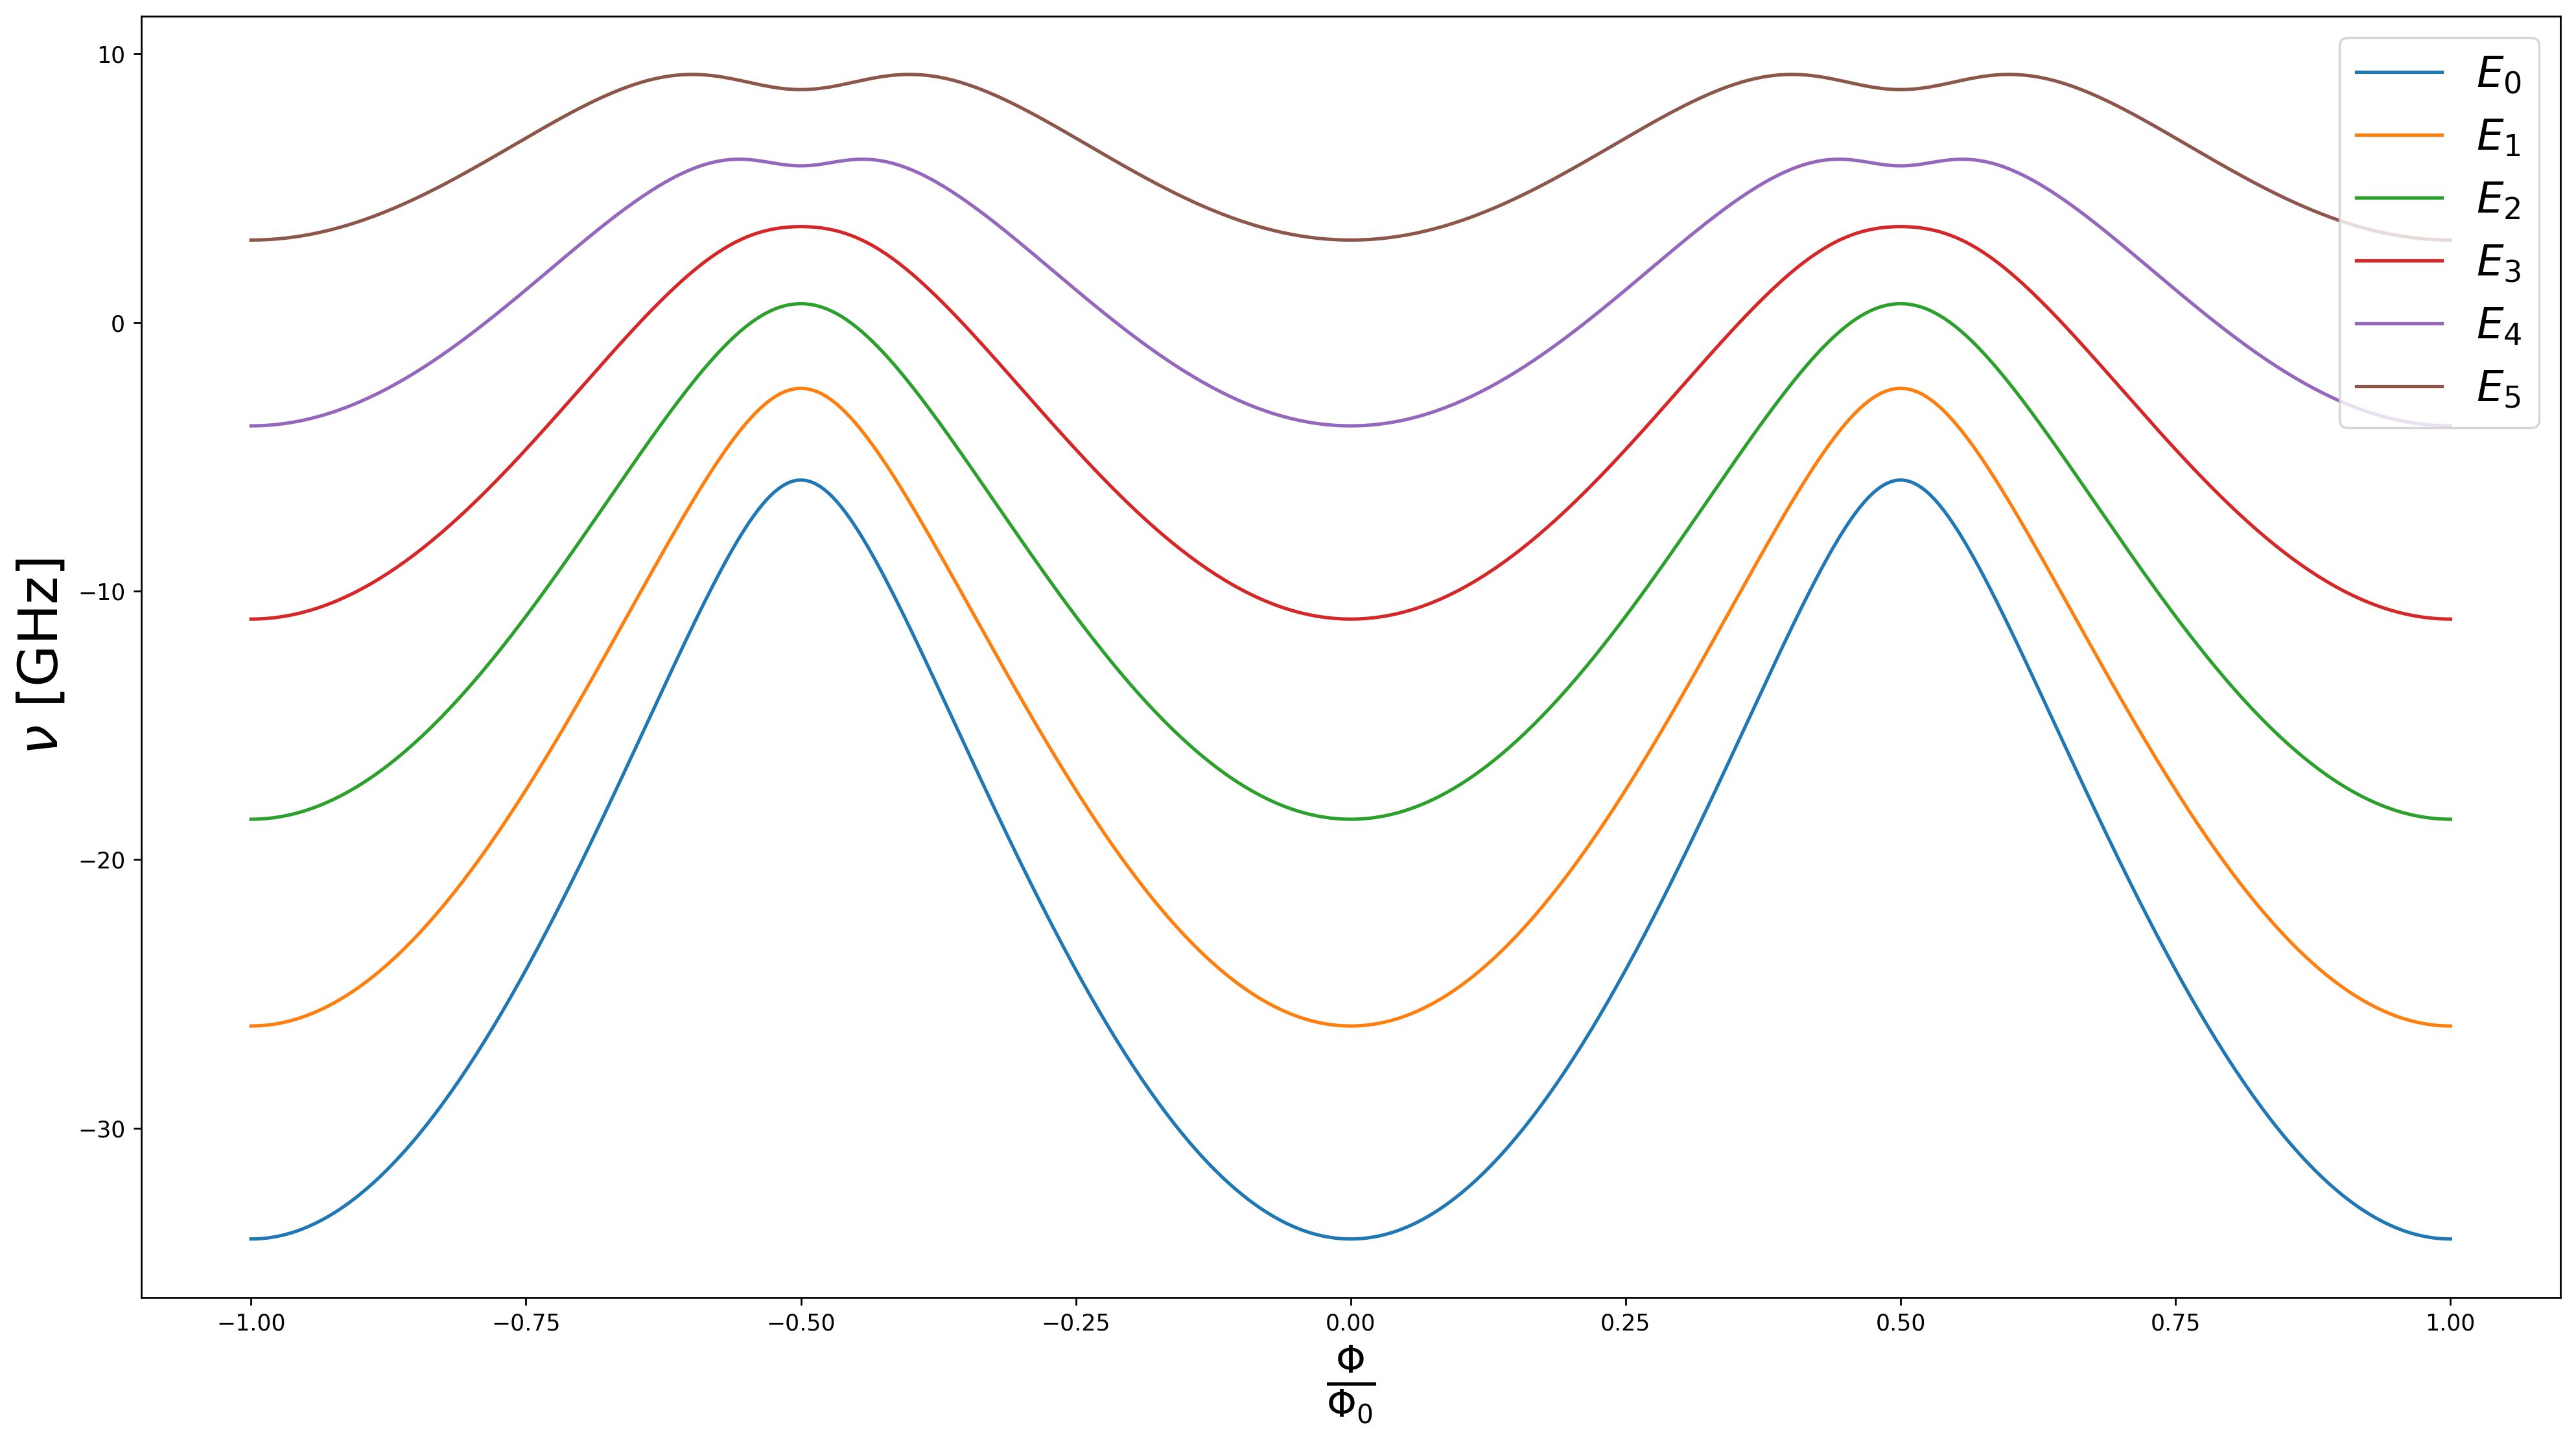

In [103]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9), dpi=250)

for i in range(0, 6):
  ax.plot(phi_list, energies[i] / 2 / pi, label=fr"$E_{{{i}}}$")

ax.set_xlabel(r"$\frac{\Phi}{\Phi_0}$", fontsize=24)
ax.set_ylabel(r"$\nu$ [GHz]", fontsize=24)
ax.legend(fontsize=19)

plt.tight_layout()
plt.show()


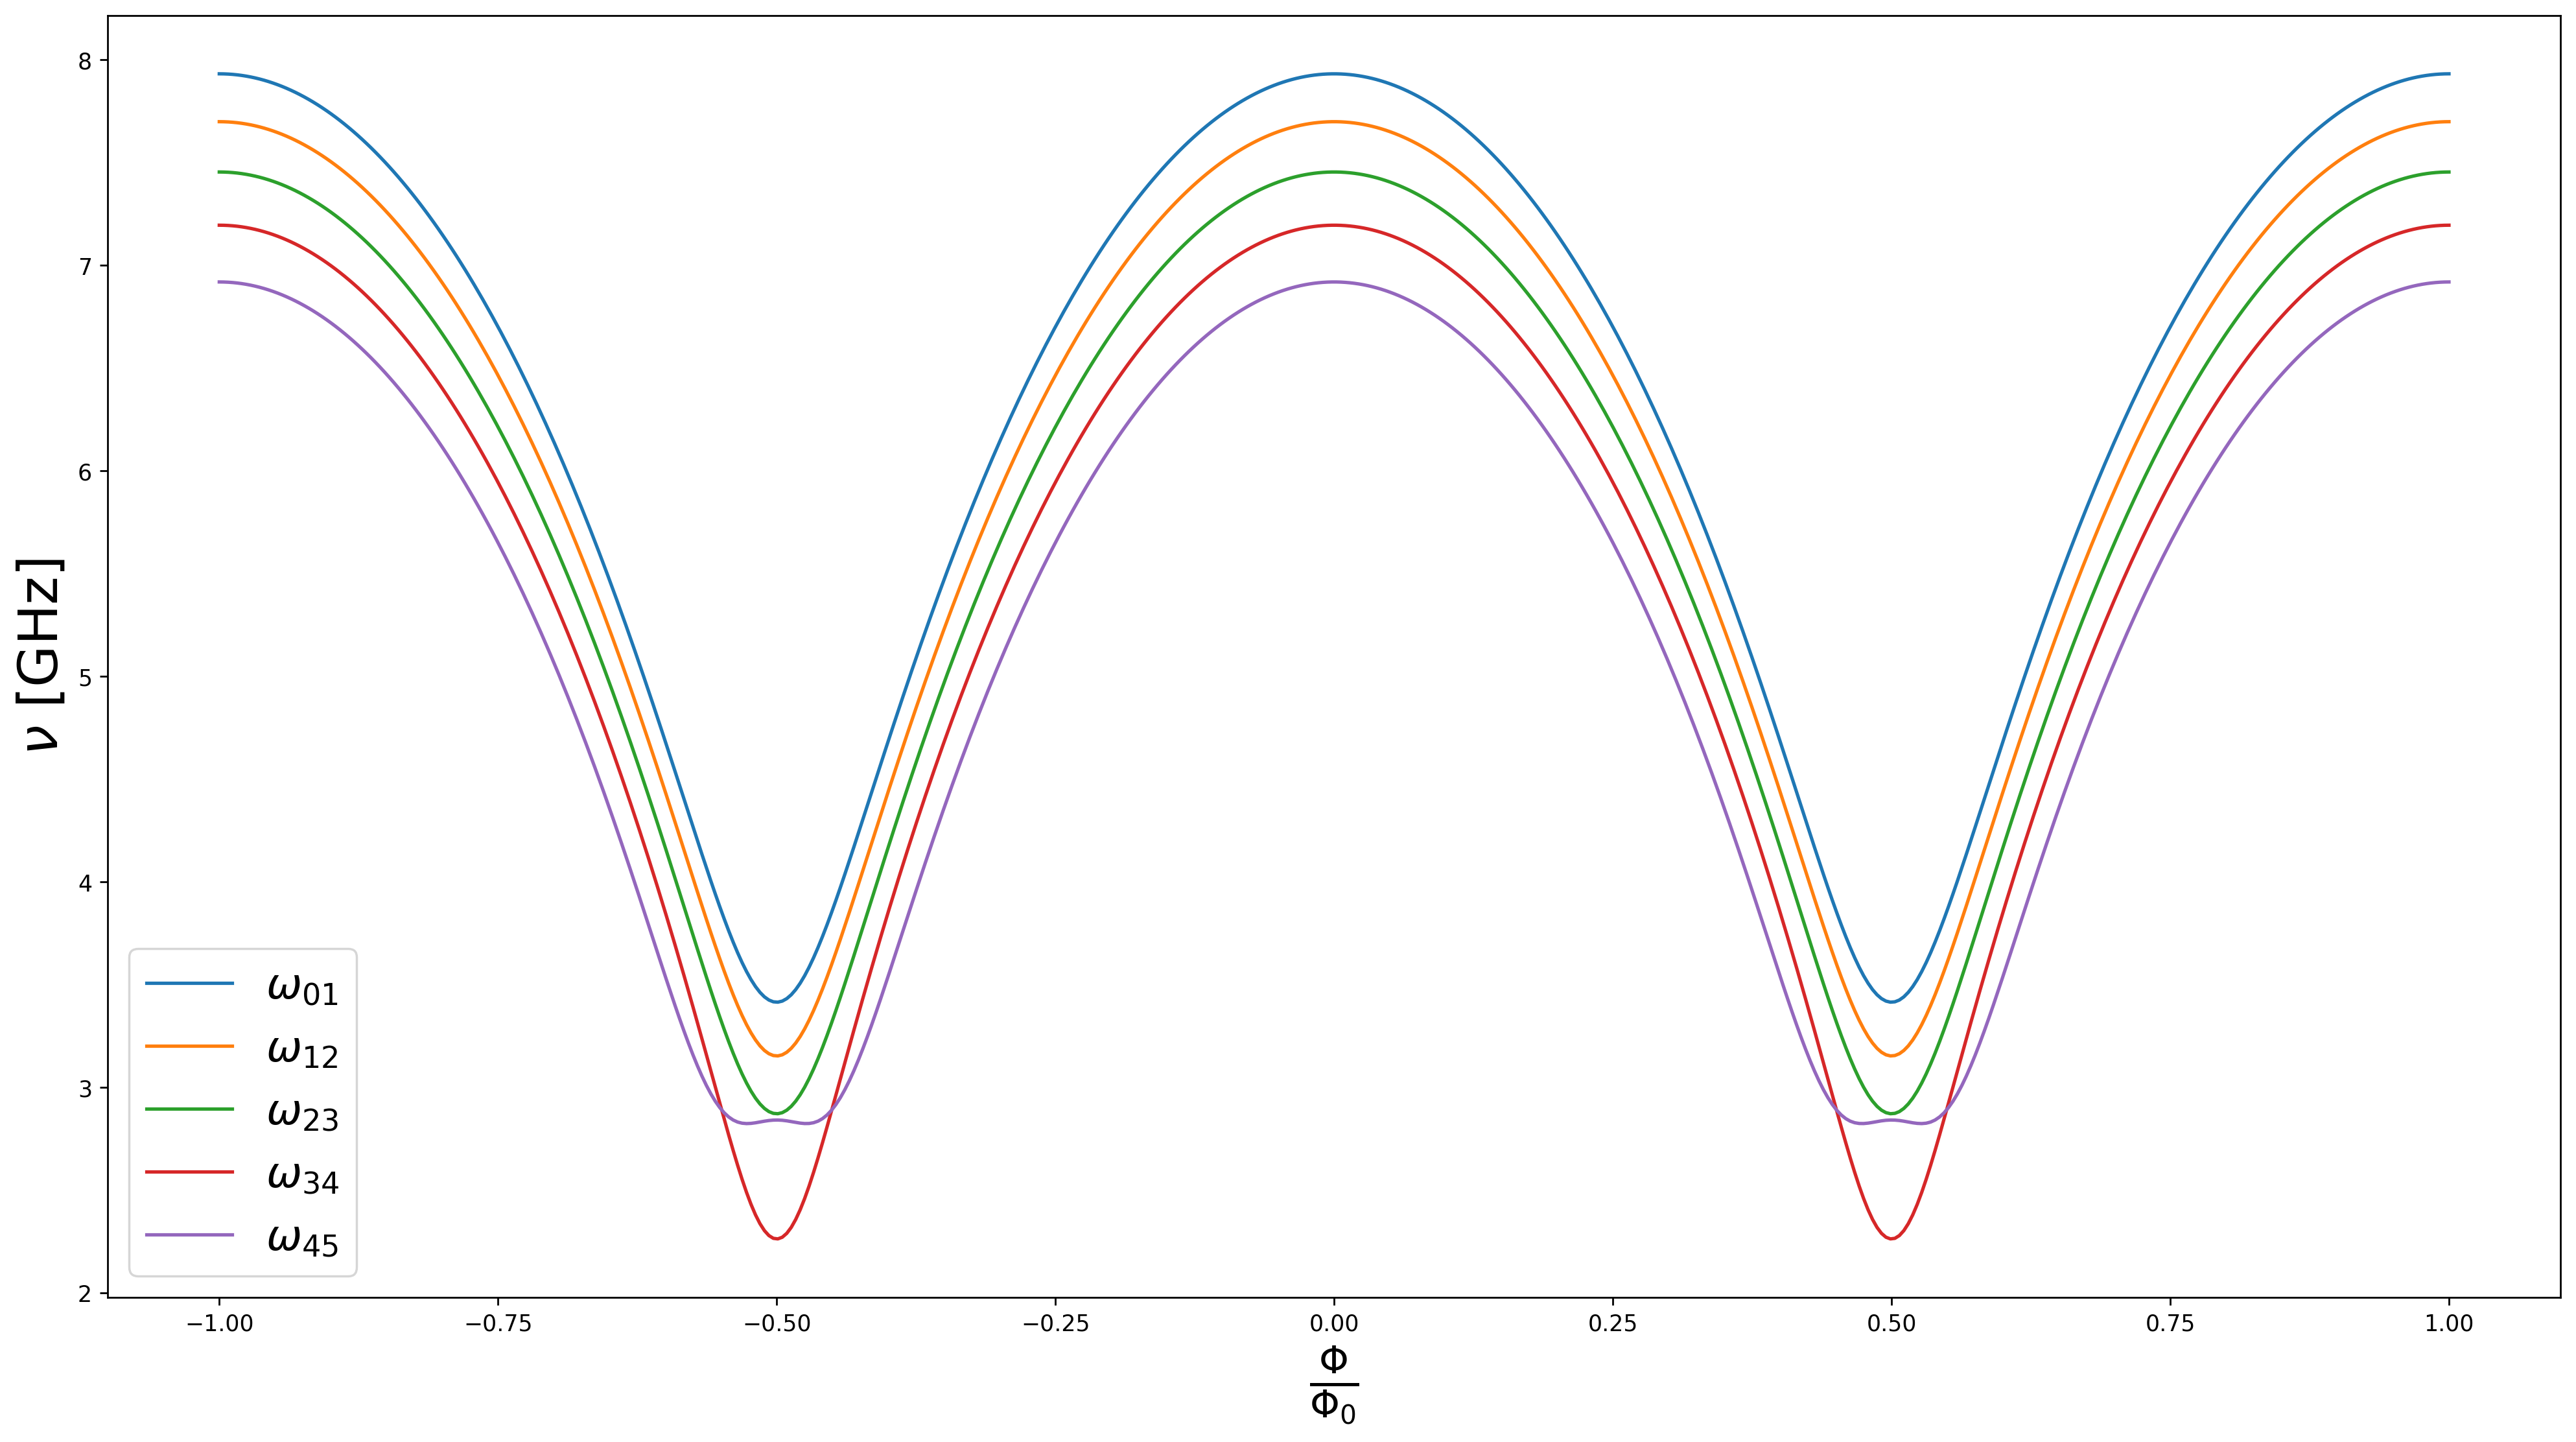

In [105]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9), dpi=250)

for i in range(1, 6):
  ax.plot(phi_list, omegas[i] / 2 / pi, label=fr"$\omega_{{{i - 1}{i}}}$")

ax.set_xlabel(r"$\frac{\Phi}{\Phi_0}$", fontsize=24)
ax.set_ylabel(r"$\nu$ [GHz]", fontsize=24)
ax.legend(fontsize=19)

plt.tight_layout()
plt.show()


In [8]:
ex = [(3,), (5, 6)]
ex2 = [*ex]
ex2

[(3,), (5, 6)]

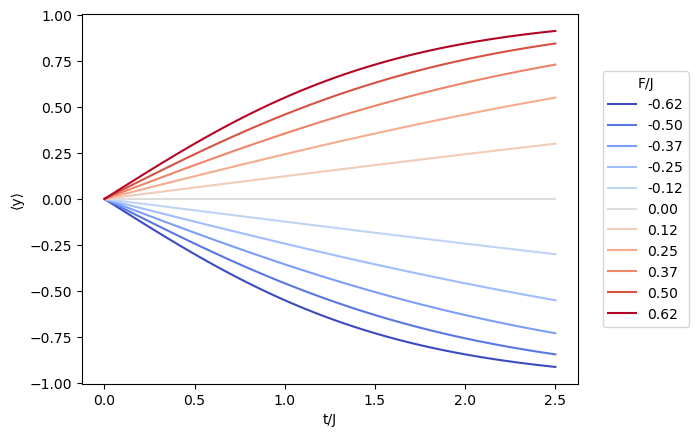

In [8]:
import matplotlib.pyplot as plt
import numpy as np

cmap = plt.get_cmap("coolwarm")  # or "seismic", "RdBu", etc.
values = np.linspace(-0.62, 0.62, 11)
colors = [cmap((v - values.min()) / (values.max() - values.min())) for v in values]
fig, ax = plt.subplots()

for v, c in zip(values, colors):
    ax.plot(np.linspace(0, 2.5, 100), np.tanh(np.linspace(0, 2.5, 100) * v), color=c, label=f"{v:.2f}")

# Place legend outside
ax.legend(title="F/J", bbox_to_anchor=(1.05, 0.5), loc="center left", borderaxespad=0)
ax.set_xlabel("t/J")
ax.set_ylabel("⟨y⟩")

plt.show()


In [50]:
ex = [(3,), (2, 7), (1, 6, 11), (0, 5, 10, 15), (4, 9, 14), (8, 13), (12,)]
ex[1:]

[(2, 7), (1, 6, 11), (0, 5, 10, 15), (4, 9, 14), (8, 13), (12,)]

In [27]:
ex = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]]).reshape(2, 2, -1)
# ex.sum(axis=0) * [0.5, 0.4]
ex[:, :, 1].sum(axis=1).flatten()

array([ 7, 19])

In [53]:
np.arange(1, 5, 1)

array([1, 2, 3, 4])

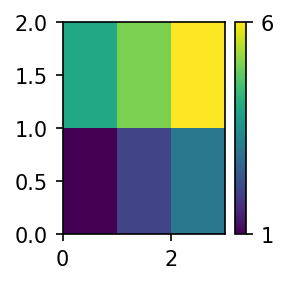

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2), dpi=150)

ex = [[1, 2, 3], [4, 5, 6]]

image = ax.pcolormesh(ex)
cbar = fig.colorbar(image)
cbar.set_ticks([1, 6])


plt.tight_layout()
plt.show()

In [28]:
ex = np.array([[0, 1, 2, 3], [4, 5, 6, 7], [8, 9, 10, 11]])
# res = []
# res.append(ex[0][::-1])
# np.array(res).T
ex[::-1]

array([[ 8,  9, 10, 11],
       [ 4,  5,  6,  7],
       [ 0,  1,  2,  3]])

In [14]:
ex = {'1': 3}
ex['1'] += 5
ex

{'1': 8}

In [11]:
print(qt.tensor(qt.destroy(3), qt.qeye(3)) * qt.tensor(qt.basis(3, 2), qt.basis(3, 1)))

Quantum object: dims=[[3, 3], [1, 1]], shape=(9, 1), type='ket', dtype=Dense
Qobj data =
[[0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [1.41421356]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]]


In [13]:
qt.tensor(qt.basis(3, 1), qt.basis(3, 1))

Quantum object: dims=[[3, 3], [1, 1]], shape=(9, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]]

In [13]:
freqs = {3: 4.79166667, 2: 4.61666667, 7: 4.61666667,
         1: 4.5, 6: 4.5, 11: 4.5,
         0: 4.675, 5: 4.675, 10: 4.675, 15: 4.675,
         4: 4.55833333, 9: 4.55833333, 14: 4.55833333,
         8: 4.73333333, 13: 4.73333333, 12: 4.85}
freqs.values()

dict_values([4.79166667, 4.61666667, 4.61666667, 4.5, 4.5, 4.5, 4.675, 4.675, 4.675, 4.675, 4.55833333, 4.55833333, 4.55833333, 4.73333333, 4.73333333, 4.85])

FileNotFoundError: [Errno 2] No such file or directory: 'untitled folder/layout-32q.png'

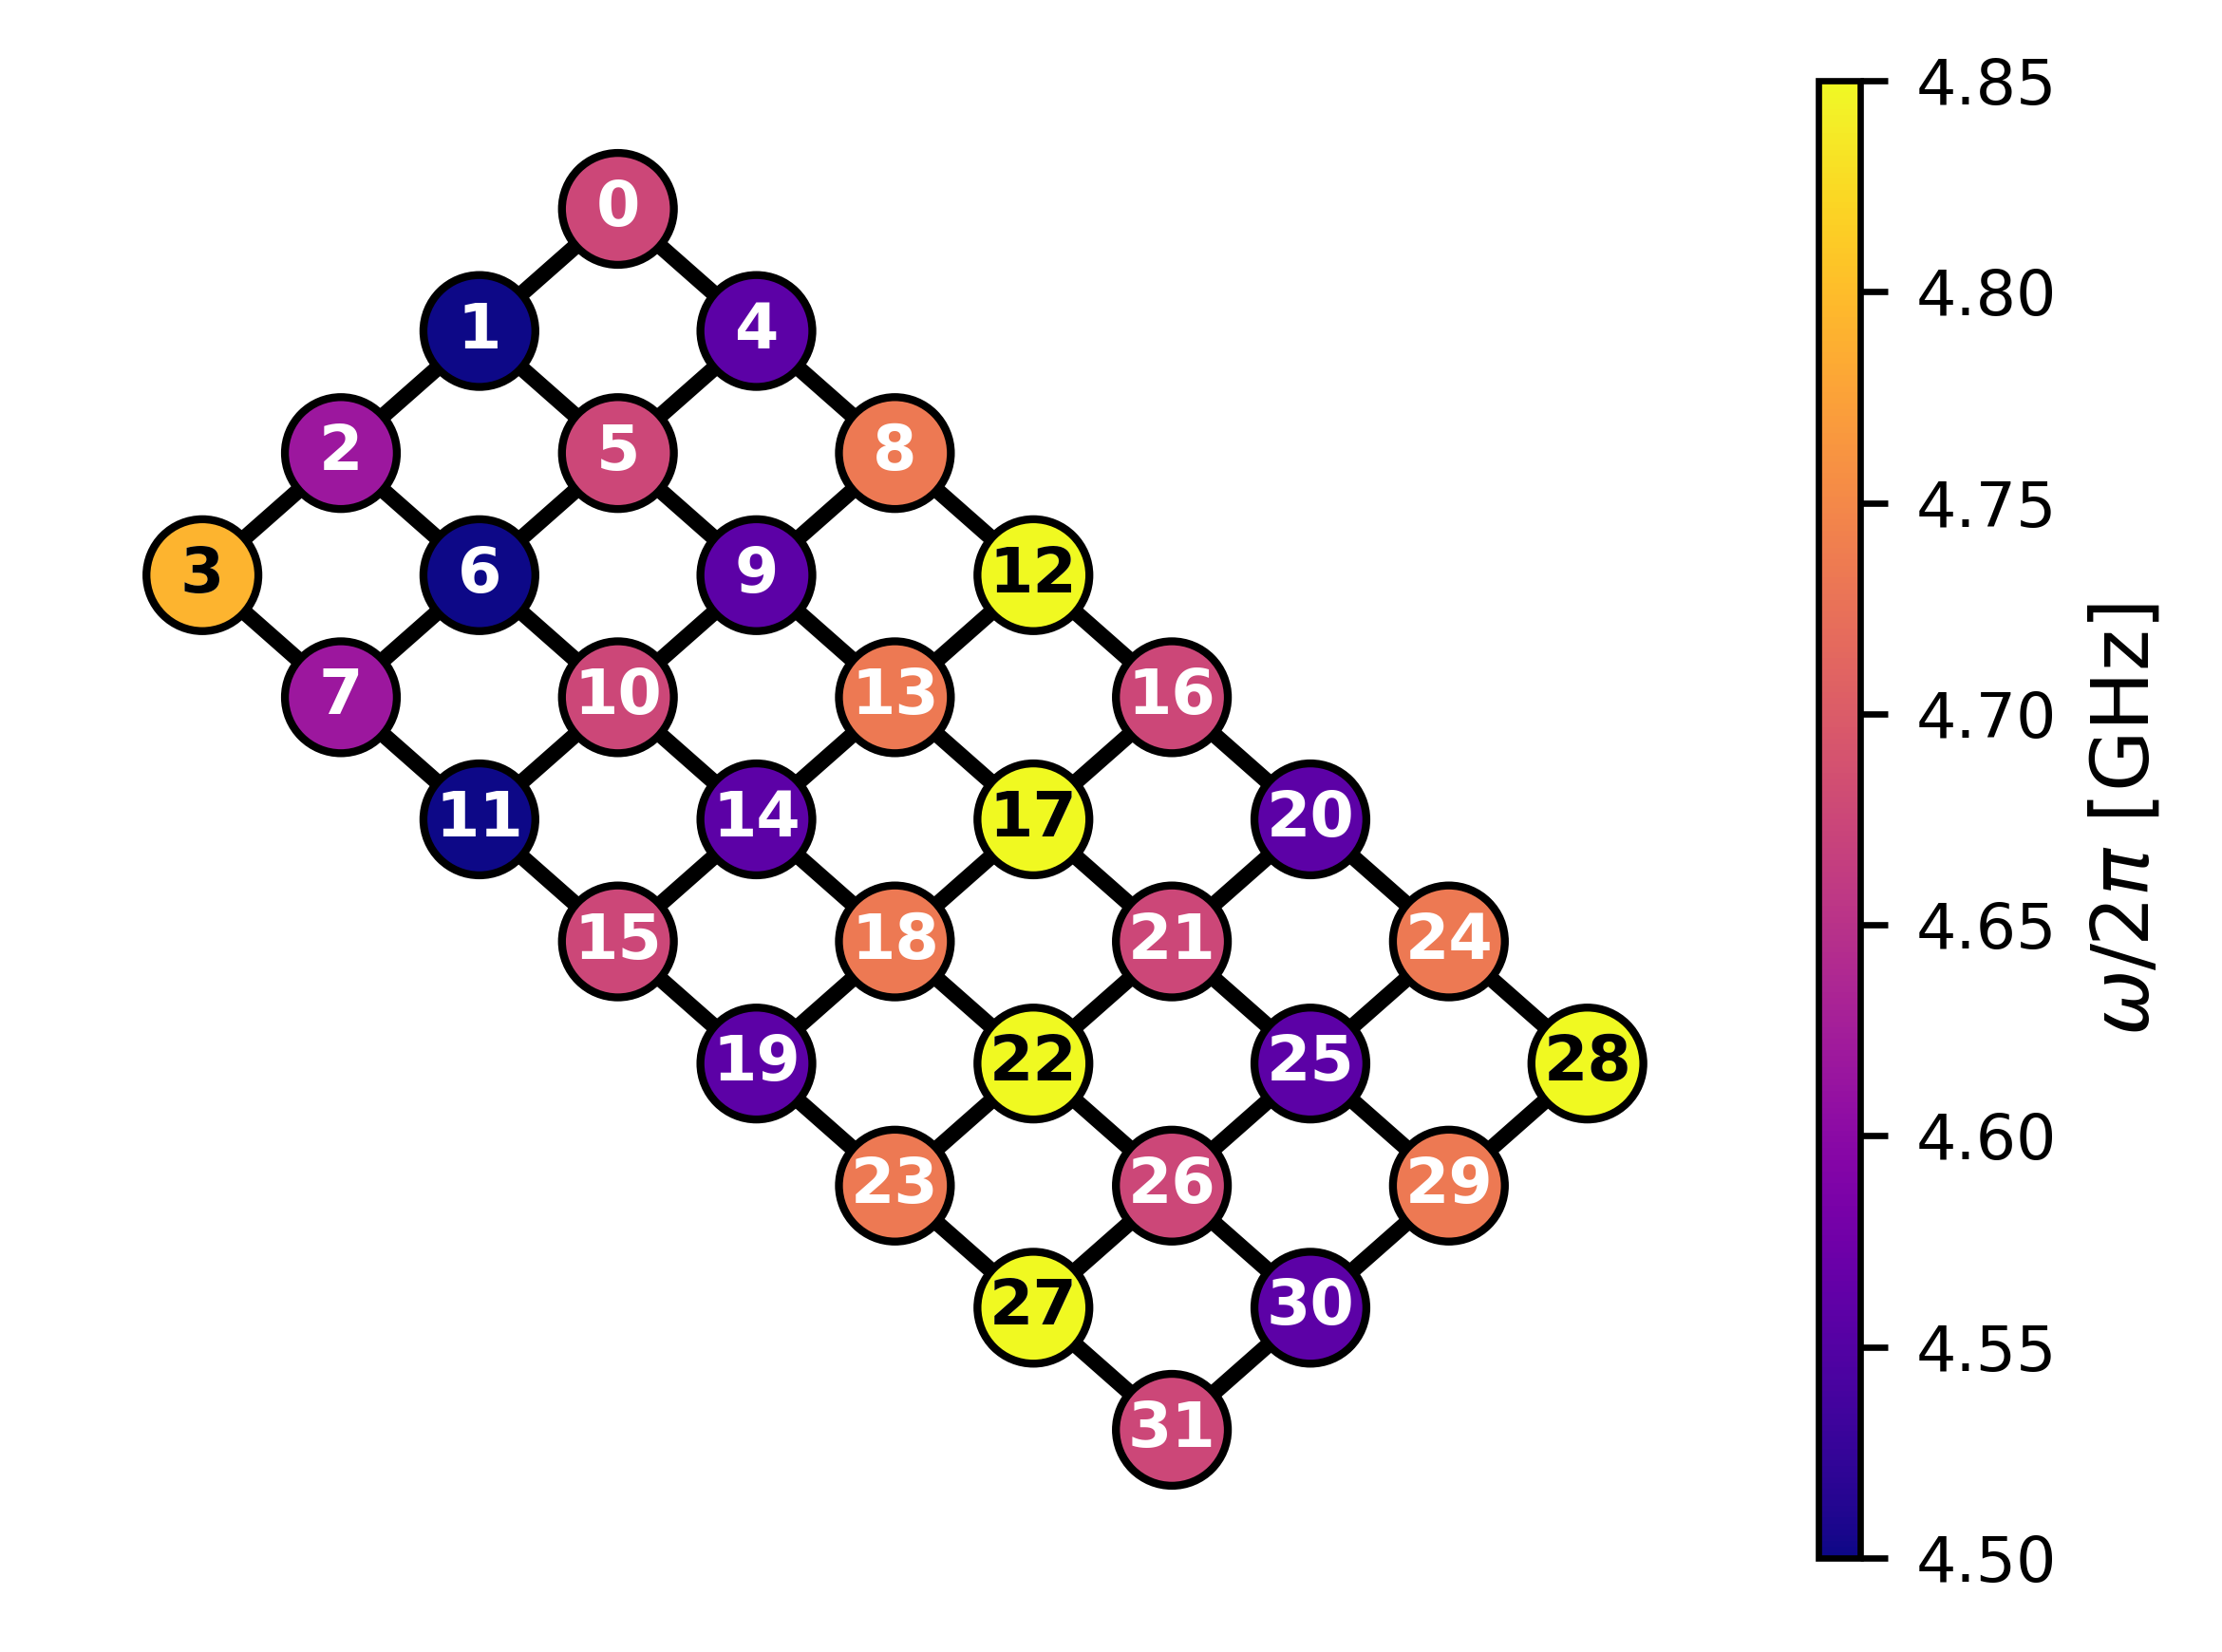

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- 1. Define the graph connectivity ---
edges = [
    (0,1), (0, 4),
    (1,2), (1,5),
    (2,3), (2,6),
    (3,7),
    (4,5), (4,8),
    (5,6), (5,9),
    (6,7), (6,10),
    (7,11),
    (8,9), (8,12),
    (9,10), (9,13),
    (10,11), (10,14),
    (11,15),
    (12,13), (12, 16),
    (13,14), (13, 17),
    (14,15), (14, 18),
    (15, 19),
    (16, 17), (16, 20),
    (17, 18), (17, 21),
    (18, 19), (18, 22),
    (19, 23),
    (20, 21), (20, 24),
    (21, 22), (21, 25),
    (22, 23), (22, 26),
    (23, 27),
    (24, 25), (24, 28),
    (25, 26), (25, 29),
    (26, 27), (26, 30),
    (27, 31),
    (28, 29),
    (29, 30),
    (30, 31)
]
G = nx.Graph()
G.add_edges_from(edges)

# --- 2. Assign some example frequencies (GHz) ---
# Use a gradient for demonstration; replace with your data
freqs = {3: 4.79166667, 2: 4.61666667, 7: 4.61666667,
         1: 4.5, 6: 4.5, 11: 4.5,
         0: 4.675, 5: 4.675, 10: 4.675, 15: 4.675,
         4: 4.55833333, 9: 4.55833333, 14: 4.55833333, 19: 4.55833333,
         8: 4.73333333, 13: 4.73333333, 18: 4.73333333, 23: 4.73333333,
         12: 4.85, 17: 4.85, 22: 4.85, 27: 4.85,
         16: 4.675, 21: 4.675, 26: 4.675, 31: 4.675,
         20: 4.55833333, 25: 4.55833333, 30: 4.55833333,
         24: 4.73333333, 29: 4.73333333,
         28: 4.85}

# --- 3. Node positions arranged like your diamond layout ---
pos = {
    0:(0,4),
    1:(-1,3), 4:(1,3),
    2:(-2,2), 5:(0,2), 8:(2,2),
    3:(-3,1), 6:(-1,1),9:(1,1),12:(3,1),
    7:(-2,0),10:(0,0),13:(2,0),
    11:(-1,-1),14:(1,-1),
    15:(0,-2),
    16: (4, 0), 17: (3, -1), 18: (2, -2), 19: (1, -3),
    20: (5, -1), 21: (4, -2), 22: (3, -3), 23: (2, -4),
    24: (6, -2), 25: (5, -3), 26: (4, -4), 27: (3, -5),
    28: (7, -3), 29: (6, -4), 30: (5, -5), 31: (4, -6),
}

# --- 4. Color mapping ---
values = np.array(list(freqs.values()))
vmin, vmax = 4.5, 4.85
cmap = plt.cm.plasma  # or 'inferno', 'viridis', etc.
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

width_px = 1200
height_px = 1200
dpi=800

# --- 5. Draw edges and nodes ---
fig, (ax_graph, ax_cbar) = plt.subplots(
    1, 2,
    figsize=(4, 3), dpi=600,
    gridspec_kw={'width_ratios':[4, 0.1]},  # wider left, narrow right
)
ax_graph.set_axis_off()
nx.draw_networkx_edges(G, pos, ax=ax_graph, width=2, edge_color="black")

node_colors = [cmap(norm(freqs[n])) for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax_graph,
                       node_color=node_colors,
                       node_size=200,
                       edgecolors="black",
                       linewidths=1)
nx.draw_networkx_labels(G, pos, ax=ax_graph,
                        labels={n:str(n) for n in G.nodes()},
                        font_size=8, font_weight='bold', font_color='white')
pos_black = {3:(-3,1), 12:(3,1), 17: (3, -1), 22: (3, -3), 27: (3, -5), 28: (7, -3)}
nx.draw_networkx_labels(G, pos=pos_black, ax=ax_graph,
                        labels={n:str(n) for n in list(pos_black.keys())},
                        font_size=8, font_weight='bold', font_color='black')

# --- 6. Add colorbar with label ---
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label(r'$\omega/2\pi$ [GHz]', fontsize=10)
cbar.ax.tick_params(labelsize=8)

# fig.colorbar(sm, ax=ax, location='right', fraction=0.05, pad=0.04)

plt.tight_layout()
plt.savefig("Results/layout-32q.png", bbox_inches='tight')


In [121]:
pos_black = {3:(-3,1), 12:(3,1), 17: (3, -1), 22: (3, -3), 27: (3, -5), 28: (7, -3)}
list(pos_black.keys())

[3, 12, 17, 22, 27, 28]

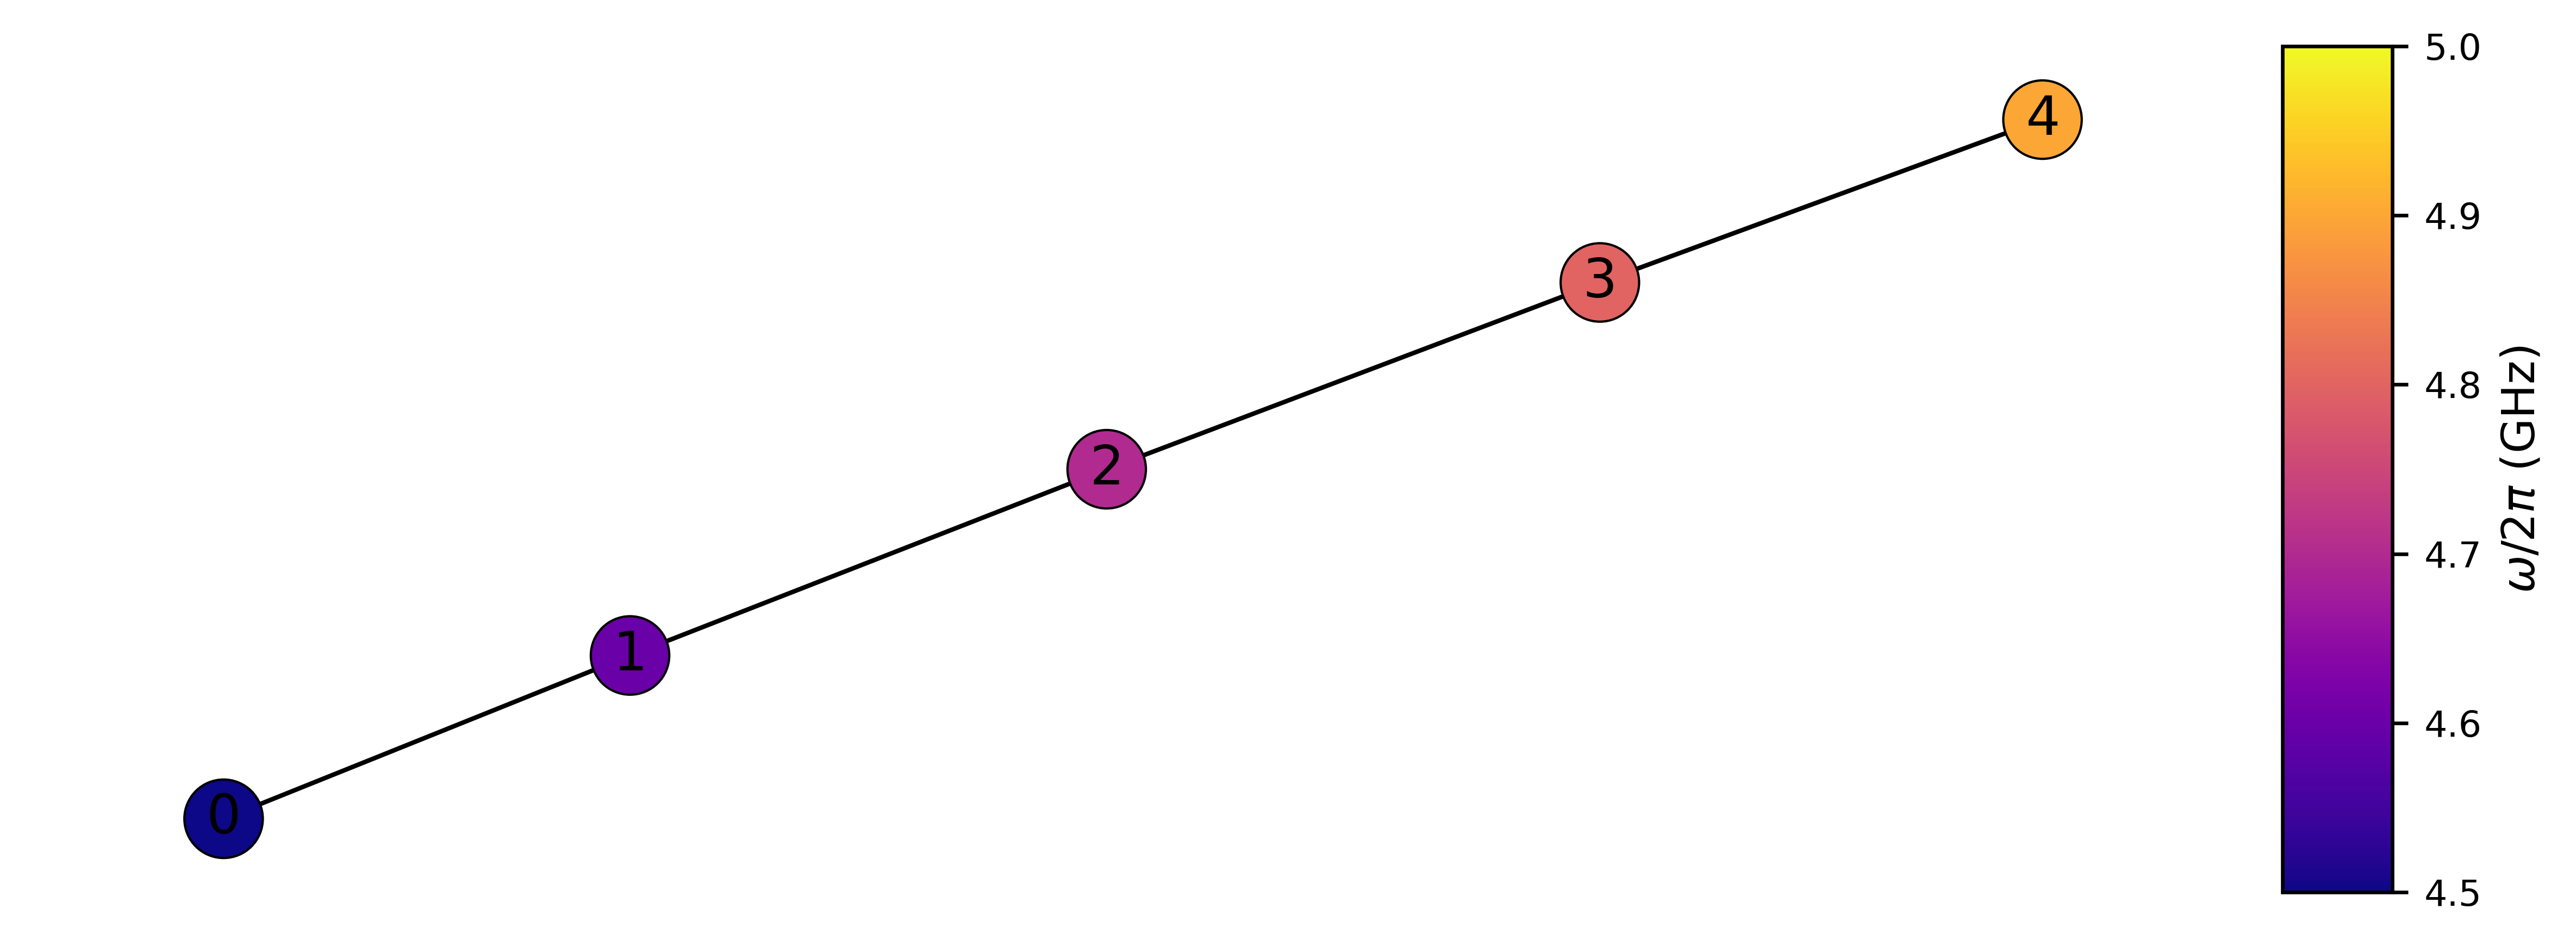

In [93]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import numpy as np

# --- Example data ---
G = nx.path_graph(5)
pos = nx.spring_layout(G)
freqs = {n:4.5+0.1*n for n in G.nodes()}

values = np.array(list(freqs.values()))
vmin, vmax = 4.5, 5.0
cmap = plt.cm.plasma
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# --- Figure with two subplots ---
fig, (ax_graph, ax_cbar) = plt.subplots(
    1, 2,
    figsize=(8, 3), dpi=600,
    gridspec_kw={'width_ratios':[20,1]},  # wider left, narrow right
)

# --- Draw graph on left subplot ---
nx.draw(
    G, pos, ax=ax_graph,
    node_color=[cmap(norm(freqs[n])) for n in G.nodes()],
    with_labels=True,
    edgecolors="black",
    linewidths=0.5
)
ax_graph.set_axis_off()

# --- Prepare ScalarMappable for colorbar ---
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

# --- Place colorbar into the *second* subplot (ax_cbar) ---
cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label(r'$\omega/2\pi$ (GHz)', fontsize=10)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


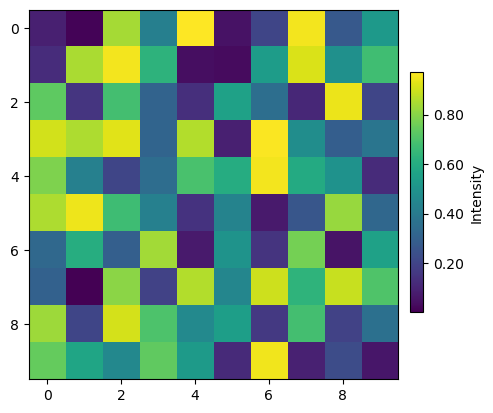

In [30]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# --- Sample data ---
data = np.random.rand(10, 10)
fig, ax = plt.subplots()

im = ax.imshow(data, cmap='viridis')

# --- Define a separate Axes for the colorbar (absolute position) ---
# [left, bottom, width, height] in figure coordinates (0–1)
cax = fig.add_axes([0.82, 0.25, 0.02, 0.5])

# --- Create colorbar there ---
cbar = fig.colorbar(im, cax=cax, format="%.2f")
cbar.set_label("Intensity")

plt.show()


In [30]:
a = np.array([qt.basis(2, 0).dag().full(), qt.basis(2, 0).dag().full(), qt.basis(2, 0).dag().full(), qt.basis(2, 1).dag().full()])
b = np.array([qt.basis(2, 0).full(), qt.basis(2, 0).full(), qt.basis(2, 0).full(), qt.basis(2, 0).full()])

In [114]:
def CreateCompositions(L, N, M):
  if L == 1:
    if 0 <= N <= M:
      yield tuple(map(tuple, qt.basis(2, N).full().T))
    return
  
  for x in np.arange(0, min(N, M) + 1):
    for tail in CreateCompositions(L - 1, N - x, M):
      yield tuple(map(tuple, qt.basis(2, x).full().T)) + tail

In [115]:
tuple(map(tuple, qt.basis(2, 0).full().T))

((np.complex128(1+0j), np.complex128(0j)),)

In [116]:
results = []

for s in range(1 + 1):
  for vec in CreateCompositions(4, s, 1):
    results.append(vec)

In [117]:
res_dict = {}

for id, comb in enumerate(results):
  res_dict[comb] = id

In [224]:
res_dict

{((np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(1+0j), np.complex128(0j))): 0,
 ((np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(0j), np.complex128(1+0j))): 1,
 ((np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(0j), np.complex128(1+0j)),
  (np.complex128(1+0j), np.complex128(0j))): 2,
 ((np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(0j), np.complex128(1+0j)),
  (np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(1+0j), np.complex128(0j))): 3,
 ((np.complex128(0j), np.complex128(1+0j)),
  (np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(1+0j), np.complex128(0j)),
  (np.complex128(1+0j), np.complex128(0j))): 4}

In [226]:
for idx, state in enumerate(res_dict):
  print(state)

((np.complex128(1+0j), np.complex128(0j)), (np.complex128(1+0j), np.complex128(0j)), (np.complex128(1+0j), np.complex128(0j)), (np.complex128(1+0j), np.complex128(0j)))
((np.complex128(1+0j), np.complex128(0j)), (np.complex128(1+0j), np.complex128(0j)), (np.complex128(1+0j), np.complex128(0j)), (np.complex128(0j), np.complex128(1+0j)))
((np.complex128(1+0j), np.complex128(0j)), (np.complex128(1+0j), np.complex128(0j)), (np.complex128(0j), np.complex128(1+0j)), (np.complex128(1+0j), np.complex128(0j)))
((np.complex128(1+0j), np.complex128(0j)), (np.complex128(0j), np.complex128(1+0j)), (np.complex128(1+0j), np.complex128(0j)), (np.complex128(1+0j), np.complex128(0j)))
((np.complex128(0j), np.complex128(1+0j)), (np.complex128(1+0j), np.complex128(0j)), (np.complex128(1+0j), np.complex128(0j)), (np.complex128(1+0j), np.complex128(0j)))


In [225]:
# for key in res_dict.keys():
#   print(np.array(key))

keys = np.array(tuple(res_dict.keys()))
state = keys[1]
state

array([[1.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])

In [173]:
op = np.array([qt.qeye(2).full()] * 4)
op[3] = qt.destroy(2).full()
op.shape

(4, 2, 2)

In [178]:
state[..., np.newaxis].shape

(4, 2, 1)

In [197]:
tmp_state = np.squeeze(np.matmul(op, state[..., np.newaxis]), axis=-1)
tmp_state.shape

(4, 2)

In [201]:
keys[0][:, np.newaxis, :].shape

(4, 1, 2)

In [206]:
np.prod(np.squeeze(np.matmul(keys[0][:, np.newaxis, :], tmp_state[..., np.newaxis]), axis=(-1, -2)))

np.complex128(1+0j)

In [214]:
states_list = np.array([qt.basis(2, 0).full()] * 4)
states_list[0] = qt.basis(2, 1).full()
states_list = np.squeeze(states_list, axis=-1)
states_list.shape

(4, 2)

In [219]:
import numpy as np
import scipy.sparse as sp
import qutip as qt

# ---- parameters ----
N = 167
tlist = np.linspace(0.0, 1.0, 51)

# ---- sparse random Hermitian Hamiltonian ----
A = sp.random(N, N, density=1e-4, format='csr', dtype=np.complex128)
H = (A + A.getH()) * 0.5
H_qobj = qt.Qobj(H)

# ---- initial pure state and density matrix ----
psi0 = qt.rand_ket(N)     # random normalized ket
rho0 = psi0.proj()        # density matrix

# ---- time evolution ----
result = qt.mesolve(H_qobj, rho0, tlist, [], [])

print("Finished.  Final state dimension:", result.states[-1].shape)


Finished.  Final state dimension: (167, 167)


In [221]:
ex = []
for i in range(2517):
  ex.append(np.zeros(2517))

ex = np.array(ex)

In [216]:
ex = np.array([1, 2, 3])
tuple(ex)

(np.int64(1), np.int64(2), np.int64(3))

In [17]:
np.vecdot(a, b)

array([[1.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])

In [4]:
np.array([2, 3]) + 5

array([7, 8])

In [5]:
arr = []
arr += [[1, 2]] + [[3, 4]]
arr


[[1, 2], [3, 4]]

In [17]:
arr1 = [[0, 1, 2], [3, 4, 5]]
prod = product(*arr1)
for item in prod:
  print(item)
  print(np.where(np.array(item) >= 2)[0])

# np.where(np.array(prod) >= 2)[0]

(0, 3)
[1]
(0, 4)
[1]
(0, 5)
[1]
(1, 3)
[1]
(1, 4)
[1]
(1, 5)
[1]
(2, 3)
[0 1]
(2, 4)
[0 1]
(2, 5)
[0 1]


In [ ]:
N_trunc = 2
number_of_qubits = 11
phis = np.linspace(0.05, 0.45, number_of_qubits)


In [4]:
create(5) * destroy(5)

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 2. 0. 0.]
 [0. 0. 0. 3. 0.]
 [0. 0. 0. 0. 4.]]

In [8]:
charge(2)**2

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dia, isherm=True
Qobj data =
[[4. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 4.]]

In [11]:
tunneling(2 * 3 + 1)

Quantum object: dims=[[7], [7]], shape=(7, 7), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0.]]

In [ ]:
_Ec = 100
_Ej = _Ec * 90
_Ns = 7
phi = 

In [ ]:
H_charge_basis = 4 * (_Ec) * charge(_Nc) ** 2 + - _Ej / 2 * tunneling(_Ns, 1) * _phi_coeff(phi)
#H_fixed_flux = Hc() + Hj(phi_base)
#evals, evecs = H_fixed_flux.eigenstates()
evals, evecs = H_charge_basis.eigenstates()
H = _truncate(H_charge_basis.transform(evecs))
_H_diag_trunc_cache[phi] = H - H[0, 0]

In [15]:
vec = basis(3, 2)
vec

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [1.]]

In [18]:
ket2dm(vec)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]

In [21]:
[1] + [2]

[1, 2]

In [22]:
charge(3)

Quantum object: dims=[[7], [7]], shape=(7, 7), type='oper', dtype=Dia, isherm=True
Qobj data =
[[-3.  0.  0.  0.  0.  0.  0.]
 [ 0. -2.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  2.  0.]
 [ 0.  0.  0.  0.  0.  0.  3.]]

In [23]:
1j * basis(2, 0) * basis(2, 1).dag() - 1j * basis(2, 1) * basis(2, 0).dag()

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.+0.j 0.+1.j]
 [0.-1.j 0.+0.j]]

In [ ]:
evecs = [basis(self._N_trunc, i) for i in range(self._N_trunc)]
return sum([abs(self.n(phi).matrix_element(evecs[j + 1], evecs[j])) /
    abs(self.n(phi).matrix_element(evecs[0], evecs[1])) *
    evecs[j + 1] * evecs[j].dag() for j in range(0, self._N_trunc - 1)])  

In [ ]:
_N_trunc = 3
_Ec = 0.09
_Ej = _Ec * 90
_d = 

def n(phi): # точное представление зарядового оператора в собственном базисе (? в энергетическом базисе)
  H_charge_basis = 4 * (_Ec) * charge(_N_trunc) ** 2 - _Ej / 2 * tunneling(_N_trunc * 2 + 1, 1) * (np.cos(0.5 * pi)**2 + (_d)**2 * np.sin(0.5 * pi) ** 2) ** 0.5
  evals, evecs = H_charge_basis.eigenstates()
  operator = Qobj(abs(charge(_N_trunc).transform(evecs)))
  _n_cache[phi] = Qobj(operator[:_N_trunc, :_N_trunc])
  return _n_cache[phi]

In [30]:
n(0)

NameError: name 'self' is not defined

In [25]:
evecs = [basis(2, i) for i in range(2)]
evecs

[Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
 Qobj data =
 [[1.]
  [0.]],
 Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
 Qobj data =
 [[0.]
  [1.]]]

In [26]:
abs(self.n(phi).matrix_element(evecs[j + 1], evecs[j]))

NameError: name 'self' is not defined

In [ ]:
H_charge_basis = 4 * (self._Ec) * charge(3) ** 2 - self._Ej / 2 * tunneling(7, 1) * (np.cos(0.5 * pi)**2 + (self._d)**2 * np.sin(0.5 * pi) ** 2) ** 0.5
evals, evecs = H_charge_basis.eigenstates()
self._n_cache[phi] = self._truncate(Qobj(abs(charge(self._Nc).transform(evecs))))

In [67]:
ex = np.array([1, 2, 3])
np.where(ex >= 2)[0]

array([1, 2])

In [68]:
idx = 0
for idx, states in enumerate(ex):
  a = 0
print(idx)

2
